In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Classification 

**Importing Libraries**

In [1]:
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import timm
import warnings
warnings.filterwarnings("ignore")

**Paths and defining classes**

In [3]:
# === PATHS ===
IMG_DIR = "/kaggle/input/datasets/karnarishita/cliniscan-all-pngs/png_images/png_images"
CSV_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv"
# === CLASSES ===
CLASSES = [
    "Aortic enlargement", "Atelectasis", "Calcification", "Cardiomegaly",
    "Consolidation", "ILD", "Infiltration", "Lung Opacity", "Nodule/Mass",
    "Other lesion", "Pleural effusion", "Pleural thickening", "Pneumothorax",
    "Pulmonary fibrosis"
]
NUM_CLASSES = len(CLASSES)

# === Load & Prepare Data ===
df = pd.read_csv(CSV_PATH)

# Keep only abnormality classes (exclude "No finding")
df = df[df["class_id"] < 14]

# Pivot to multi-label format
df_multi = df.pivot_table(
    index="image_id",
    columns="class_name",
    aggfunc="size",
    fill_value=0
).reset_index()
# Convert to binary (1 if present, 0 otherwise)
df_multi[CLASSES] = (df_multi[CLASSES] > 0).astype(int)

# Add all images (including those with no findings)
all_images = pd.DataFrame({"image_id": [f.stem for f in Path(IMG_DIR).glob("*.png")]})
df_full = all_images.merge(df_multi, on="image_id", how="left").fillna(0)

# Add path column
df_full["path"] = df_full["image_id"].apply(lambda x: os.path.join(IMG_DIR, x + ".png"))
df_full = df_full[df_full["path"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total usable images: {len(df_full)}")
print("Class distribution:\n", df_full[CLASSES].sum())

Total usable images: 15000
Class distribution:
 Aortic enlargement    3067.0
Atelectasis            186.0
Calcification          452.0
Cardiomegaly          2300.0
Consolidation          353.0
ILD                    386.0
Infiltration           613.0
Lung Opacity          1322.0
Nodule/Mass            826.0
Other lesion          1134.0
Pleural effusion      1032.0
Pleural thickening    1981.0
Pneumothorax            96.0
Pulmonary fibrosis    1617.0
dtype: float64


**Training using Efficient Net-B2**

In [5]:
# Train / Val split
train_df, val_df = train_test_split(df_full, test_size=0.15, random_state=42, stratify=df_full[CLASSES].idxmax(axis=1))

# === Dataset ===
class VinDrMultiLabelDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        label = torch.tensor(row[CLASSES].values.astype(np.float32))  # multi-hot
        if self.transform:
            img = self.transform(img)
        return img, label

**Transformations**

In [ ]:

train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ds = VinDrMultiLabelDataset(train_df, train_transform)
val_ds   = VinDrMultiLabelDataset(val_df,   val_transform)

train_loader = DataLoader(train_ds, batch_size=24, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# === Model ===
model = timm.create_model("efficientnet_b2", pretrained=True, num_classes=NUM_CLASSES)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# === Loss with class weights (helps imbalance) ===
pos_weight = torch.tensor([10.0] * NUM_CLASSES).to(device)  # adjust per class if needed
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = torch.cuda.amp.GradScaler()

**Training**

In [5]:

epochs = 5
best_auc = 0.0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            outs = model(imgs)
            loss = criterion(outs, lbls)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * imgs.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_preds, val_trues = [], []
    
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(device)
            outs = model(imgs)
            probs = torch.sigmoid(outs)
            val_preds.append(probs.cpu())
            val_trues.append(lbls.cpu())
    
    val_preds = torch.cat(val_preds).numpy()
    val_trues = torch.cat(val_trues).numpy()
    
    # Metrics
    auc = roc_auc_score(val_trues, val_preds, average='macro', multi_class='ovr')
    f1 = f1_score(val_trues, (val_preds > 0.5).astype(int), average='macro', zero_division=0)
    acc = accuracy_score(val_trues.ravel(), (val_preds > 0.5).ravel())
    
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Mean AUC (macro): {auc:.4f}")
    print(f"Val F1 (macro): {f1:.4f}")
    print(f"Val Flat Accuracy: {acc:.4f}")
    
    scheduler.step()
    
    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "/kaggle/working/efficientnet_best_multi_label.pth")
        print("Saved best model!")

print("\nTraining Complete")
print(f"Best Mean AUC: {best_auc:.4f}")

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Epoch 1/5:   0%|          | 0/532 [00:00<?, ?it/s]


Epoch 1/5
Train Loss: 0.6512
Val Mean AUC (macro): 0.9202
Val F1 (macro): 0.4096
Val Flat Accuracy: 0.8725
Saved best model!


Epoch 2/5:   0%|          | 0/532 [00:00<?, ?it/s]


Epoch 2/5
Train Loss: 0.4670
Val Mean AUC (macro): 0.9361
Val F1 (macro): 0.4600
Val Flat Accuracy: 0.8814
Saved best model!


...


Epoch 3/5
Train Loss: 0.4050
Val Mean AUC (macro): 0.9441
Val F1 (macro): 0.4724
Val Flat Accuracy: 0.8738
Saved best model!


Epoch 4/5:   0%|          | 0/532 [00:00<?, ?it/s]


Epoch 4/5
Train Loss: 0.3559
Val Mean AUC (macro): 0.9458
Val F1 (macro): 0.5107
Val Flat Accuracy: 0.9070
Saved best model!


Epoch 5/5:   0%|          | 0/532 [00:00<?, ?it/s]


Epoch 5/5
Train Loss: 0.3110
Val Mean AUC (macro): 0.9480
Val F1 (macro): 0.5191
Val Flat Accuracy: 0.9058
Saved best model!

Training Complete
Best Mean AUC: 0.9480


In [7]:

print(f" Mean AUC  : {auc:.4f}")
print(f" F1 Score  : {f1:.4f}")
print(f" Accuracy  : {acc:.4f}")

 Mean AUC  : 0.9480
 F1 Score  : 0.5191
 Accuracy  : 0.9058


In [8]:
# CELL 2 — Constants + val_loader recreation
IMG_DIR  = "/kaggle/input/datasets/karnarishita/cliniscan-all-pngs/png_images/png_images"
CSV_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv"

CLASSES = [
    "Aortic enlargement", "Atelectasis", "Calcification", "Cardiomegaly",
    "Consolidation", "ILD", "Infiltration", "Lung Opacity", "Nodule/Mass",
    "Other lesion", "Pleural effusion", "Pleural thickening", "Pneumothorax",
    "Pulmonary fibrosis"
]
NUM_CLASSES = len(CLASSES)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate val_df
df = pd.read_csv(CSV_PATH)
df = df[df["class_id"] < 14]
df_multi = df.pivot_table(index="image_id", columns="class_name",
                           aggfunc="size", fill_value=0).reset_index()
df_multi[CLASSES] = (df_multi[CLASSES] > 0).astype(int)
all_images = pd.DataFrame({"image_id": [f.stem for f in Path(IMG_DIR).glob("*.png")]})
df_full = all_images.merge(df_multi, on="image_id", how="left").fillna(0)
df_full["path"] = df_full["image_id"].apply(lambda x: os.path.join(IMG_DIR, x + ".png"))
df_full = df_full[df_full["path"].apply(os.path.exists)].reset_index(drop=True)
_, val_df = train_test_split(df_full, test_size=0.15, random_state=42,
                              stratify=df_full[CLASSES].idxmax(axis=1))

# Dataset class
class VinDrMultiLabelDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        label = torch.tensor(row[CLASSES].values.astype(np.float32))
        if self.transform:
            img = self.transform(img)
        return img, label

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_ds     = VinDrMultiLabelDataset(val_df, val_transform)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Val samples: {len(val_ds)}")

Val samples: 2250


**Visualization Matrix and ROC curves**

Class                          AUC       F1
Aortic enlargement          0.9782   0.8091
Atelectasis                 0.9611   0.4675
Calcification               0.9082   0.2794
Cardiomegaly                0.9782   0.7824
Consolidation               0.9691   0.4530
ILD                         0.9351   0.3897
Infiltration                0.9427   0.4498
Lung Opacity                0.9327   0.5051
Nodule/Mass                 0.9158   0.4025
Other lesion                0.9120   0.4156
Pleural effusion            0.9707   0.6619
Pleural thickening          0.9368   0.6030
Pneumothorax                0.9901   0.4828
Pulmonary fibrosis          0.9417   0.5653
MEAN                        0.9480   0.5191


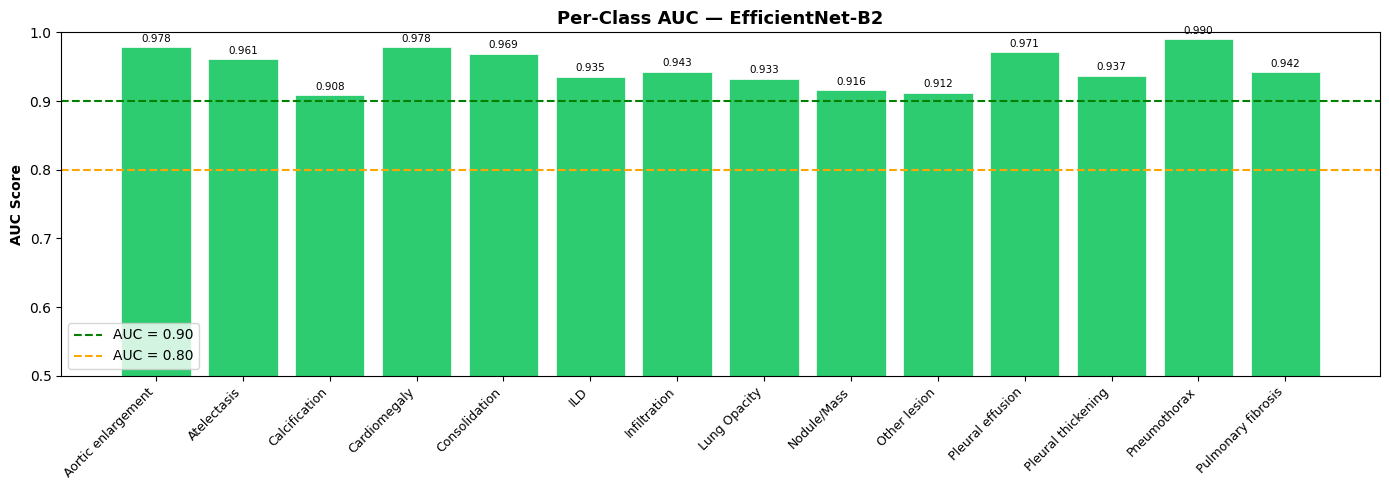

Saved → per_class_auc.png


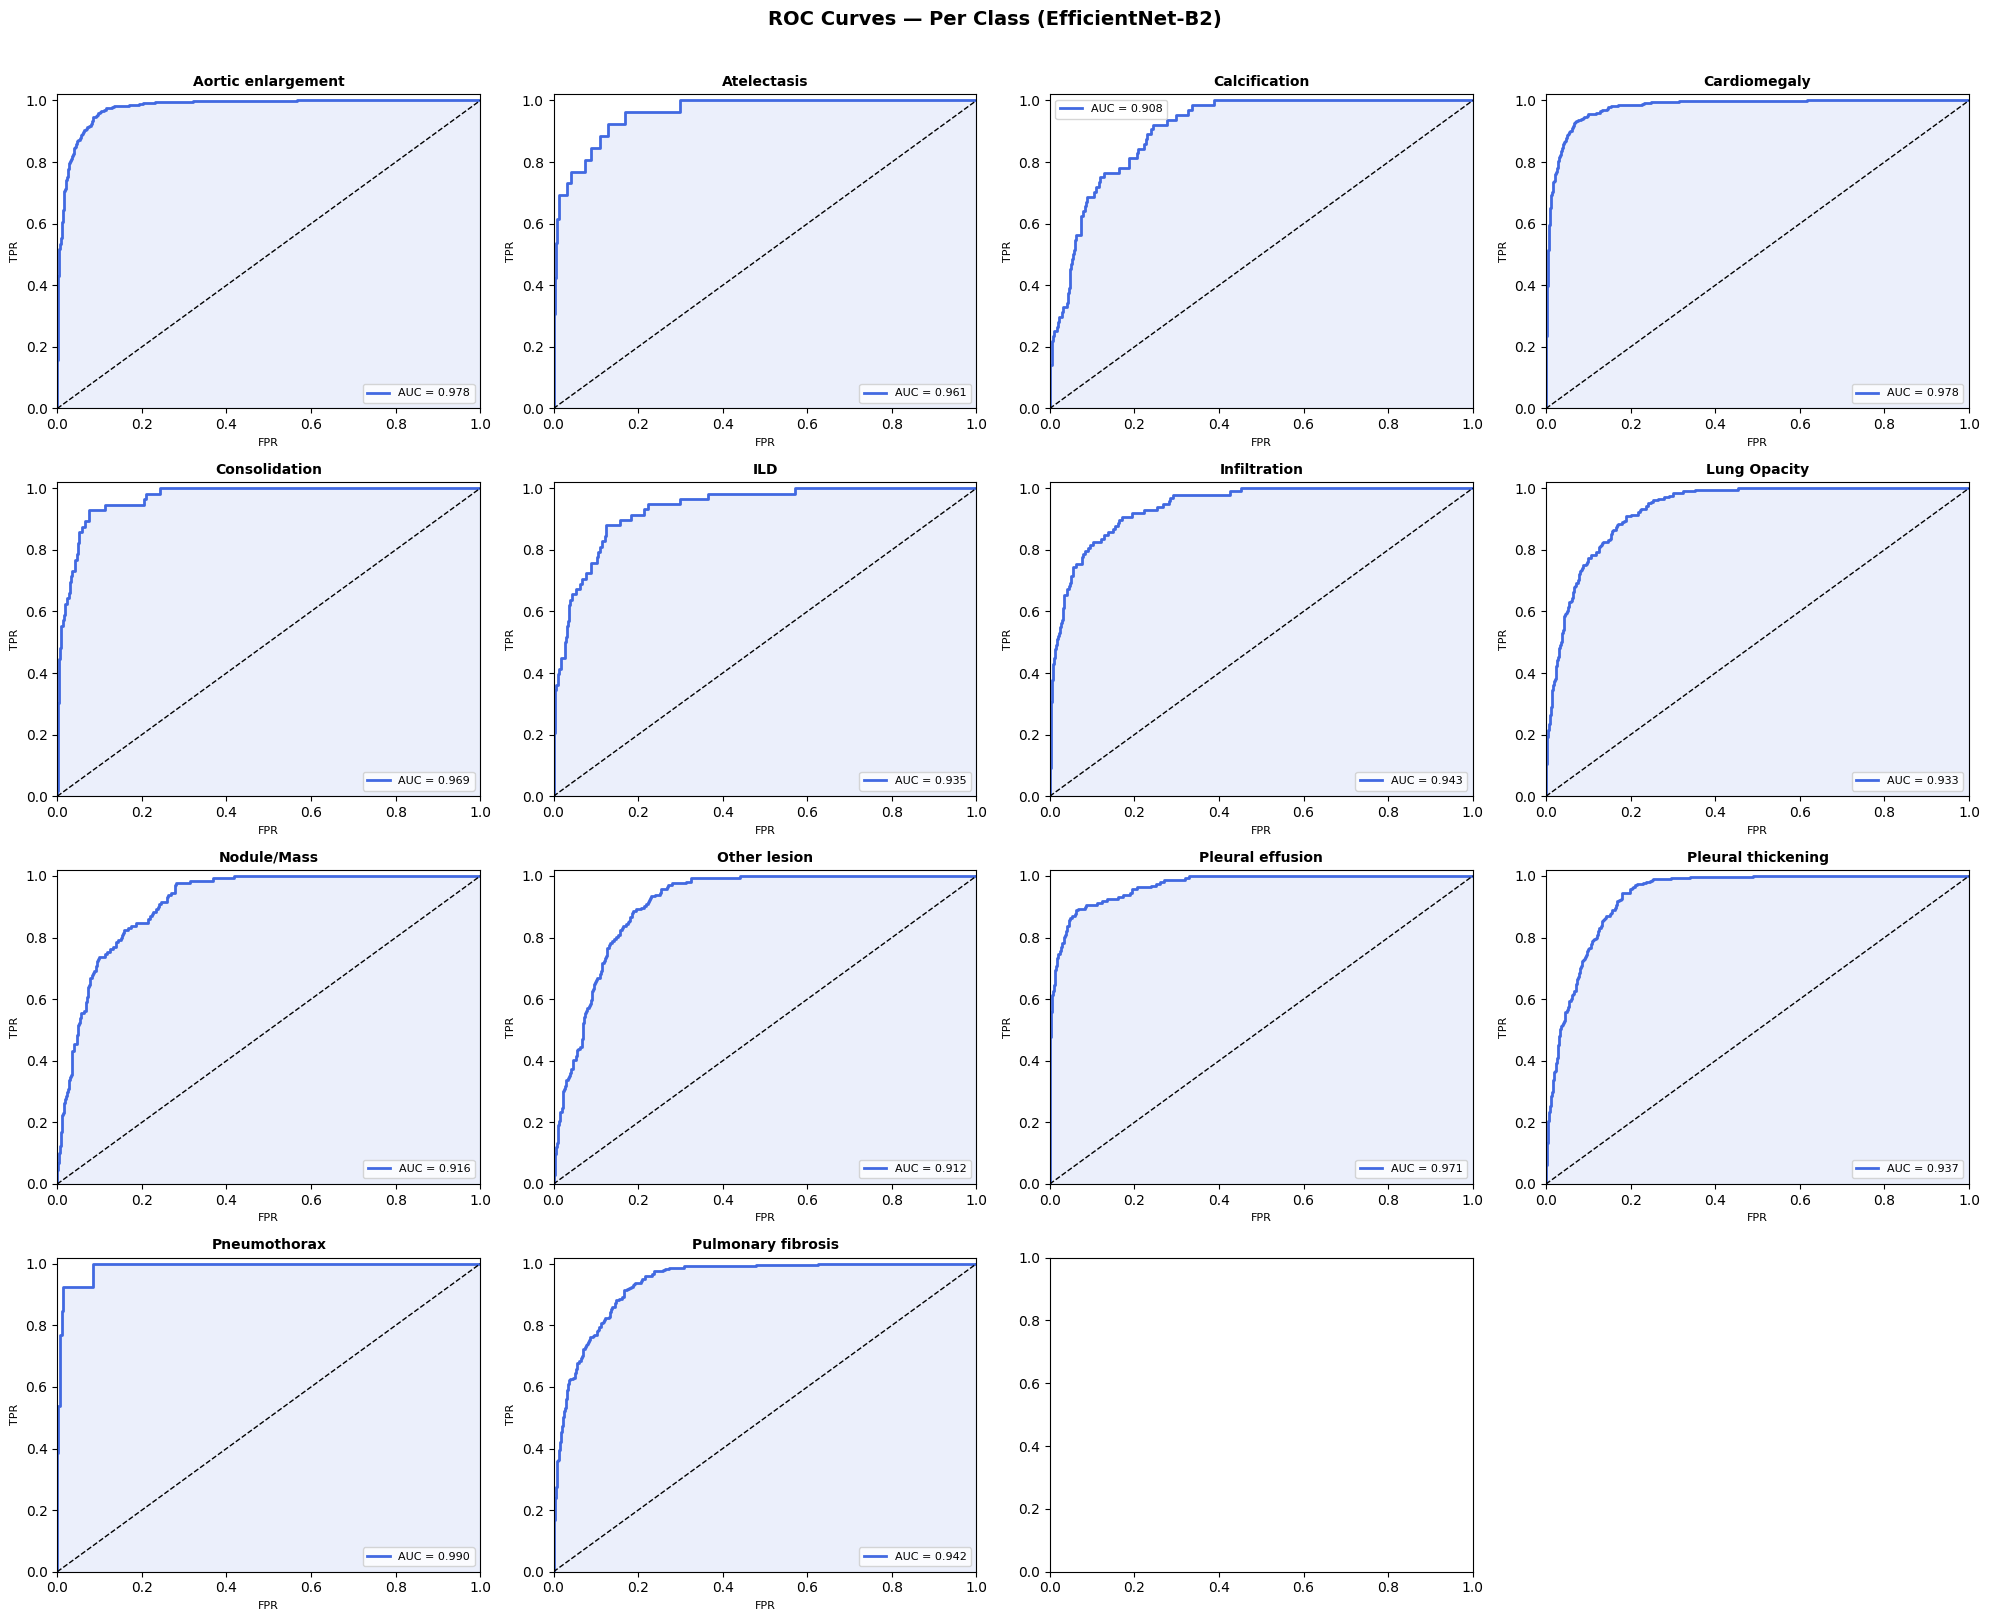

Saved → roc_curves.png


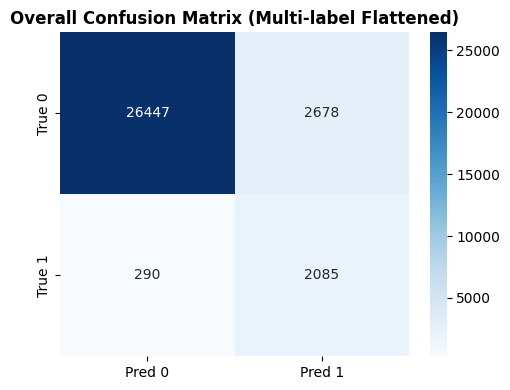

   Mean AUC : 0.9480
   Mean F1  : 0.5191


In [11]:

# === Load best model ===
model_eval = timm.create_model("efficientnet_b2", pretrained=False, num_classes=NUM_CLASSES)
model_eval.load_state_dict(torch.load("/kaggle/input/datasets/karnarishita/last-model/efficientnet_best_multi_label.pth", map_location=device))
model_eval = model_eval.to(device)
model_eval.eval()

# === Get predictions on val set ===
val_preds, val_trues = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs = imgs.to(device)
        outs = model_eval(imgs)
        probs = torch.sigmoid(outs)
        val_preds.append(probs.cpu())
        val_trues.append(lbls.cpu())

val_preds  = torch.cat(val_preds).numpy()
val_trues  = torch.cat(val_trues).numpy()
val_binary = (val_preds > 0.5).astype(int)

# ── 1A: Per-class AUC & F1 table ─────────────────────────────
print("=" * 55)
print(f"{'Class':<25} {'AUC':>8} {'F1':>8}")
print("=" * 55)
aucs, f1s = [], []
for i, cls in enumerate(CLASSES):
    try:
        auc = roc_auc_score(val_trues[:, i], val_preds[:, i])
    except:
        auc = 0.0
    f1  = f1_score(val_trues[:, i], val_binary[:, i], zero_division=0)
    aucs.append(auc)
    f1s.append(f1)
    print(f"{cls:<25} {auc:>8.4f} {f1:>8.4f}")

print("=" * 55)
print(f"{'MEAN':<25} {np.mean(aucs):>8.4f} {np.mean(f1s):>8.4f}")

# ── 1B: Per-class AUC Bar Chart ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#2ecc71" if a >= 0.90 else "#f39c12" if a >= 0.80 else "#e74c3c"
          for a in aucs]
bars = ax.bar(CLASSES, aucs, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(y=0.9, color="green",  linestyle="--", lw=1.5, label="AUC = 0.90")
ax.axhline(y=0.8, color="orange", linestyle="--", lw=1.5, label="AUC = 0.80")
ax.set_ylim([0.5, 1.0])
ax.set_ylabel("AUC Score", fontweight="bold")
ax.set_title("Per-Class AUC — EfficientNet-B2", fontsize=13, fontweight="bold")
ax.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=9)
ax.legend()
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)
plt.tight_layout()
plt.savefig("/kaggle/working/per_class_auc.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved → per_class_auc.png")

# ── 1C: ROC Curves — all 14 classes ──────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, cls in enumerate(CLASSES):
    try:
        fpr, tpr, _ = roc_curve(val_trues[:, i], val_preds[:, i])
        axes[i].plot(fpr, tpr, color="royalblue", lw=2,
                     label=f"AUC = {aucs[i]:.3f}")
        axes[i].plot([0,1],[0,1],"k--", lw=1)
        axes[i].fill_between(fpr, tpr, alpha=0.1, color="royalblue")
        axes[i].set_title(cls, fontsize=10, fontweight="bold")
        axes[i].set_xlabel("FPR", fontsize=8)
        axes[i].set_ylabel("TPR", fontsize=8)
        axes[i].legend(fontsize=8)
        axes[i].set_xlim([0, 1])
        axes[i].set_ylim([0, 1.02])
    except:
        axes[i].set_title(f"{cls} (skip)", fontsize=9)

axes[-1].axis("off")
plt.suptitle("ROC Curves — Per Class (EfficientNet-B2)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved → roc_curves.png")

# ── 1D: Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(val_trues.ravel(), val_binary.ravel())
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"], ax=ax)
ax.set_title("Overall Confusion Matrix (Multi-label Flattened)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"   Mean AUC : {np.mean(aucs):.4f}")
print(f"   Mean F1  : {np.mean(f1s):.4f}")